# t-SNE для атакованных vs оригинальных выборок

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import Ellipse

In [9]:
# Укажите пути к данным (при необходимости сохраните X_orig / X_adv после запуска attack_run)
X_ORIG_PATH = "/Users/mirus/Desktop/dev/gen-adv-attacks/results/Strawberry/ResidualCNN/attack/train_attack_test/visualizations/model_ResidualCNN_1000_Strawberry_attack_train_attack__eps=1/X_orig.npy"
X_ADV_PATH  = "/Users/mirus/Desktop/dev/gen-adv-attacks/results/Strawberry/ResidualCNN/attack/train_attack_test/visualizations/model_ResidualCNN_1000_Strawberry_attack_train_attack__eps=1/X_adv.npy"
Y_PATH = "/Users/mirus/Desktop/dev/gen-adv-attacks/results/Strawberry/ResidualCNN/attack/train_attack_test/visualizations/model_ResidualCNN_1000_Strawberry_attack_train_attack__eps=1/y_true.npy"
MAX_POINTS = 4000

def _load_array(path):
    if path in (None, "", False):
        return None
    if path.endswith((".pt", ".pth")):
        import torch
        return torch.load(path, map_location="cpu")
    return np.load(path)

def _to_numpy(arr):
    if arr is None:
        return None
    if hasattr(arr, "detach"):
        arr = arr.detach().cpu()
    return np.asarray(arr)

X_orig = _to_numpy(_load_array(X_ORIG_PATH))
X_adv = _to_numpy(_load_array(X_ADV_PATH))
y_true = _to_numpy(_load_array(Y_PATH)) if Y_PATH else None

def flatten_batch(x):
    x = np.asarray(x)
    return x.reshape(len(x), -1)

X_orig_flat = flatten_batch(X_orig)
X_adv_flat = flatten_batch(X_adv)

def downsample(x, max_points):
    if len(x) <= max_points:
        return x
    idx = np.random.choice(len(x), size=max_points, replace=False)
    return x[idx]

X_orig_flat = downsample(X_orig_flat, MAX_POINTS)
X_adv_flat = downsample(X_adv_flat, MAX_POINTS)

labels = np.concatenate([
    np.zeros(len(X_orig_flat), dtype=int),
    np.ones(len(X_adv_flat), dtype=int),
])
X_all = np.concatenate([X_orig_flat, X_adv_flat], axis=0)

scaler = StandardScaler()
X_all_scaled = scaler.fit_transform(X_all)

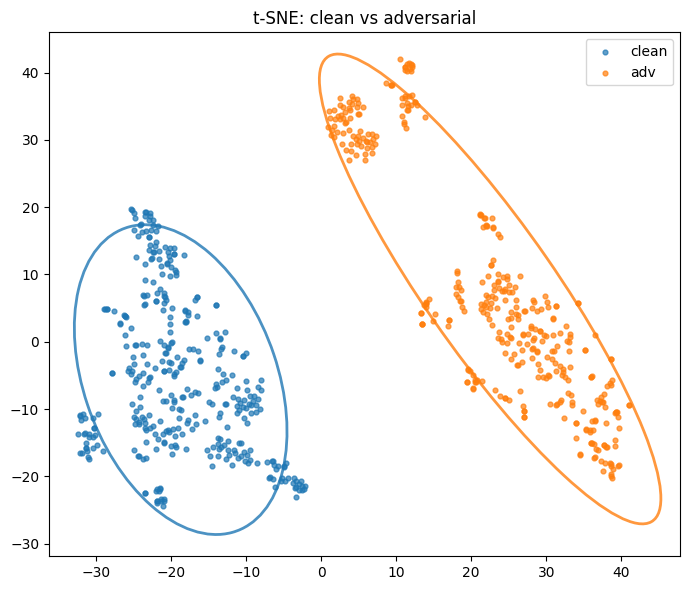

In [10]:
# Тут нужно установить ненулевое значение, чтобы отсмотреть переход оригинальных точек в атаковвнныен
MAX_ARROWS = 0
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="random",
    random_state=42,
)
emb_tsne = tsne.fit_transform(X_all_scaled)

def plot_ellipse(points, ax, color, n_std=2.0, **kwargs):
    cov = np.cov(points, rowvar=False)
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(vals)
    ellipse = Ellipse(
        xy=points.mean(axis=0),
        width=width,
        height=height,
        angle=theta,
        facecolor="none",
        edgecolor=color,
        linewidth=2,
        alpha=0.8,
        **kwargs,
    )
    ax.add_patch(ellipse)

fig, ax = plt.subplots(figsize=(7, 6))
palette = {0: "tab:blue", 1: "tab:orange"}
names = {0: "clean", 1: "adv"}
for lbl in (0, 1):
    mask = labels == lbl
    pts = emb_tsne[mask]
    ax.scatter(pts[:, 0], pts[:, 1], s=12, alpha=0.7, label=names[lbl], color=palette[lbl])
    if len(pts) > 2:
        plot_ellipse(pts, ax, palette[lbl])

n_clean = len(X_orig_flat)
n_adv = len(X_adv_flat)
n_pairs = min(n_clean, n_adv)
if n_pairs > 0:
    clean_idx = np.arange(n_pairs)
    adv_idx = n_clean + np.arange(n_pairs)
    if n_pairs > MAX_ARROWS:
        np.random.seed(42)
        sample_ids = np.random.choice(n_pairs, size=MAX_ARROWS, replace=False)
        clean_idx = clean_idx[sample_ids]
        adv_idx = adv_idx[sample_ids]
    for ci, ai in zip(clean_idx, adv_idx):
        ax.arrow(
            emb_tsne[ci, 0], emb_tsne[ci, 1],
            emb_tsne[ai, 0] - emb_tsne[ci, 0],
            emb_tsne[ai, 1] - emb_tsne[ci, 1],
            color="gray", alpha=0.35, linewidth=0.8, length_includes_head=True,
            head_width=0.8, head_length=1.0,
        )

ax.set_title("t-SNE: clean vs adversarial")
ax.legend()
plt.tight_layout()
plt.show()